# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [56]:
# Import the library
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

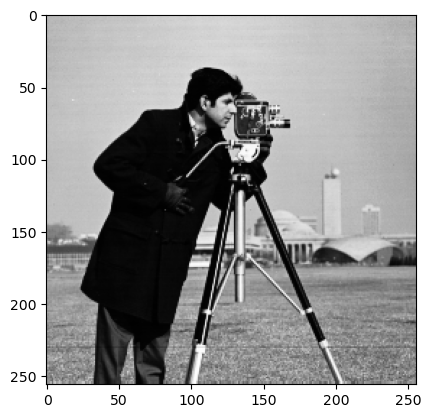

In [7]:
# ── Load image ────────────────────────────────────
img1 = Image.open('cameraman.png')
plt.imshow(img1, cmap = cm.Greys_r)
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [20]:
# Get the size of the image
w, h = img1.size
print(f"The size of the image (width,height): ({w},{h})")

# scaling factors
scaling_factor = 2

# a function that increases the image size by a given factor
def sample_image(image, factor):
    '''Increase the image size by the given factor'''
    width, height = image.size
    new_w = width * factor
    new_h = height * factor
    new_size = (new_w, new_h)
    sampled_image = image.resize(new_size, Image.Resampling.LANCZOS)
    return sampled_image

The size of the image (width,height): (256,256)


In [21]:
# ── 1. Increase size (scale ×2) ────────────────────

# ── 2. Resize the image using PIL's built-in method

'''The function sample_image is used to solve 1 & 2'''
scaled_img = sample_image(img1, scaling_factor)

The size of the scaled image (width,height): (512,512)


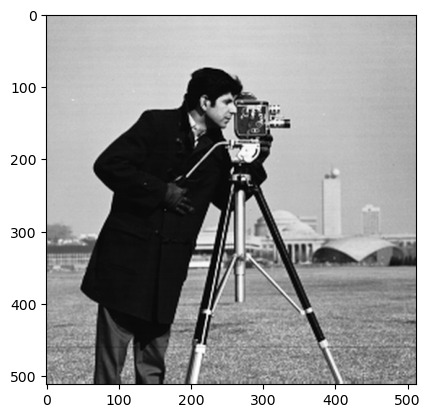

In [27]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

# Display the new image size
scaled_w, scaled_h = scaled_img.size
print(f"The size of the scaled image (width,height): ({scaled_w},{scaled_h})")

# Disply the scaled image
plt.imshow(scaled_img, cmap = cm.Greys_r)
plt.show()

# Save the image
scaled_img.save('task1_1_scaled.jpg')

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [22]:
# a function for non-uniform scaling
def non_uniform_scaling(image, cx, cy):
    '''Increase the image size by the given factor'''
    width, height = image.size
    new_w = width * cx
    new_h = height * cy
    new_size = (new_w, new_h)
    sampled_image = image.resize(new_size, Image.Resampling.LANCZOS)
    return sampled_image

In [23]:
# Apply non-uniform scaling
non_uniform_img = non_uniform_scaling(img1, 2, 1)

The size of the scaled image (width,height): (512,256)


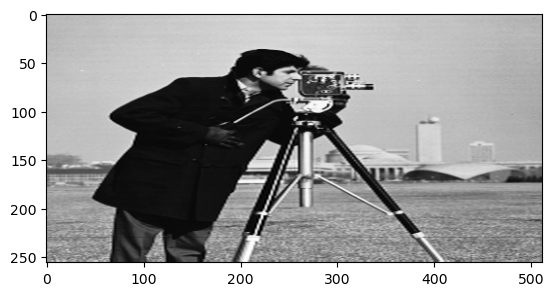

In [26]:
# New sizes
scaled_w, scaled_h = non_uniform_img.size
print(f"The size of the scaled image (width,height): ({scaled_w},{scaled_h})")

# Disply the scaled image
plt.imshow(non_uniform_img, cmap = cm.Greys_r)
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

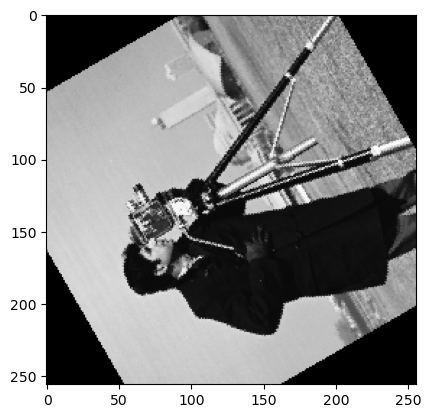

In [25]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img1.rotate(120)
rotated_img.save("task1_2_rotated.jpg")

# Disply the rotated image
plt.imshow(rotated_img, cmap = cm.Greys_r)
plt.show()

### 3. Shear

In [28]:
# -- c. Get the image dimensions ────────────────────
w, h = img1.size
print(f"The size of the image (width,height): ({w},{h})")


The size of the image (width,height): (256,256)


In [31]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0

In [33]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
matrix = (1, shx, 0,
          shy, 1,   0)

sheared_image = img1.transform(
    (w, h),
    Image.Transform.AFFINE,
    matrix
)

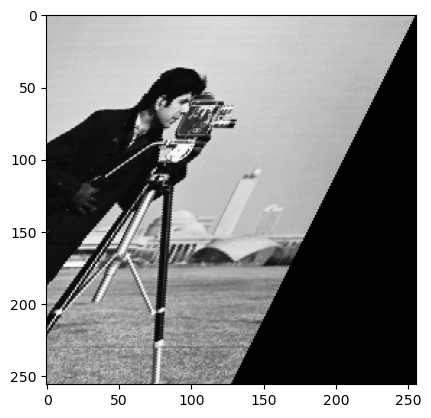

In [35]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
# Disply the sheared image
plt.imshow(sheared_image, cmap = cm.Greys_r)
plt.show()

# Save the image
sheared_image.save('task1_3_sheared.jpg')

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

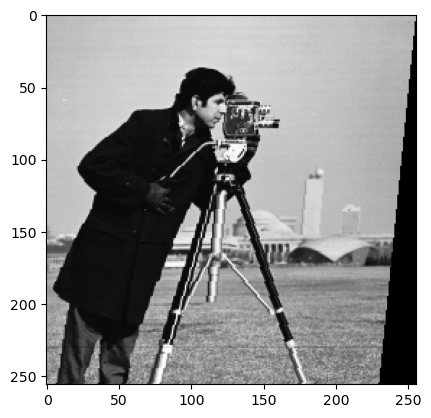

In [39]:
# shx = 0.1

shx = 0.1
matrix = (1, shx, 0,
          shy, 1,   0)

sheared_image = img1.transform(
    (w, h),
    Image.Transform.AFFINE,
    matrix
)

plt.imshow(sheared_image, cmap = cm.Greys_r)
plt.show()

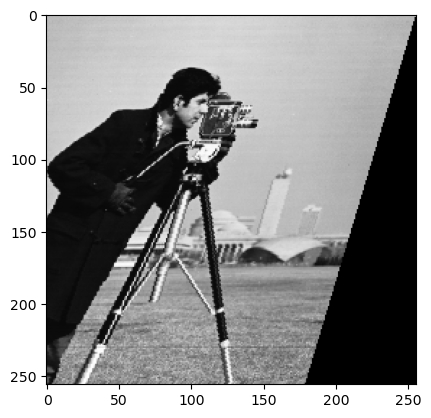

In [40]:
# shx = 0.3

shx = 0.3
matrix = (1, shx, 0,
          shy, 1,   0)

sheared_image = img1.transform(
    (w, h),
    Image.Transform.AFFINE,
    matrix
)

plt.imshow(sheared_image, cmap = cm.Greys_r)
plt.show()

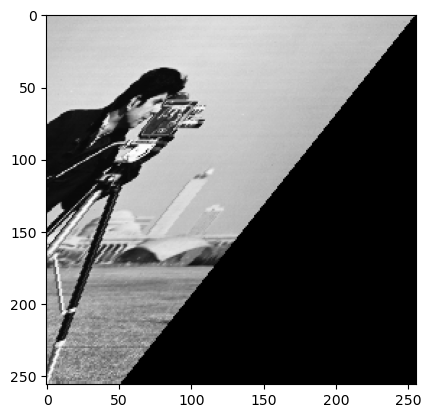

In [41]:
# shx = 0.8

shx = 0.8
matrix = (1, shx, 0,
          shy, 1,   0)

sheared_image = img1.transform(
    (w, h),
    Image.Transform.AFFINE,
    matrix
)

plt.imshow(sheared_image, cmap = cm.Greys_r)
plt.show()

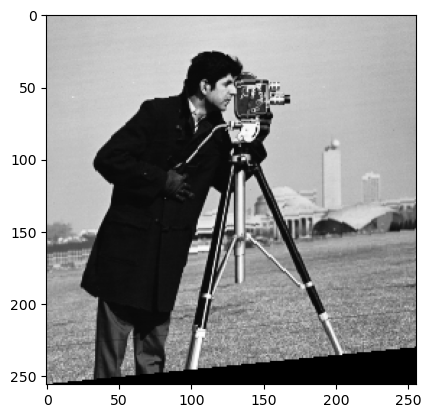

In [44]:
# Switch from X-axis to Y-axis shear matrix

shx = 0
shy = 0.1
matrix = (1, shx, 0,
          shy, 1,   0)

sheared_image = img1.transform(
    (w, h),
    Image.Transform.AFFINE,
    matrix
)

plt.imshow(sheared_image, cmap = cm.Greys_r)
plt.show()

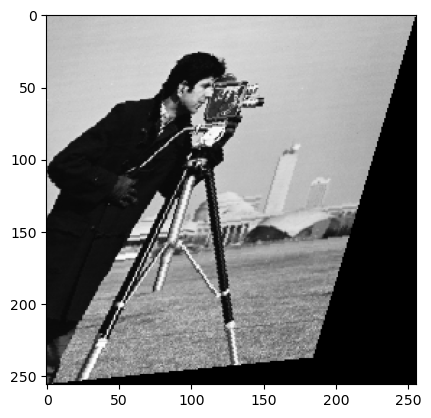

In [55]:
# combining X and Y shear in one matrix

shx = 0.3
shy = 0.1

matrix = (1, shx, 0,
          shy, 1, 0)


sheared_image = img1.transform(
    (w, h),
    Image.Transform.AFFINE,
    matrix
)

plt.imshow(sheared_image, cmap=cm.Greys_r)
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

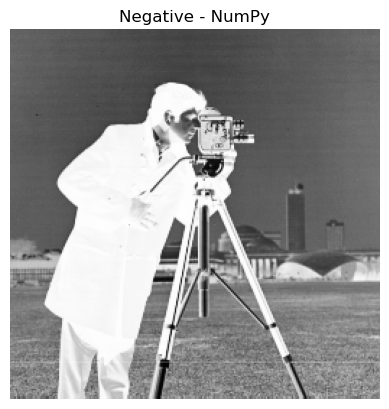

In [59]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_arr = np.array(img1)
negative = 255 - img_arr

plt.imshow(negative, cmap='gray')
plt.title("Negative - NumPy")
plt.axis("off")
plt.show()

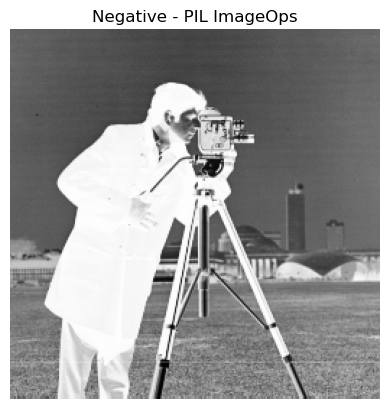

In [60]:
# Method 2: PIL's ImageOps

negative_pil = ImageOps.invert(img1)

plt.imshow(negative_pil, cmap='gray')
plt.title("Negative - PIL ImageOps")
plt.axis("off")
plt.show()

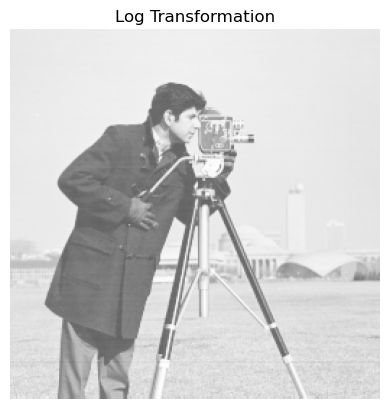

In [62]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c = 255 / np.log(1 + 255)
img_arr = np.array(img1)


# Apply the log transformation to each pixel
log_image = c * np.log(1 + img_arr)

# Convert to image and display it
log_image = Image.fromarray(log_image)
plt.imshow(log_image, cmap='gray')
plt.title("Log Transformation")
plt.axis("off")
plt.show()

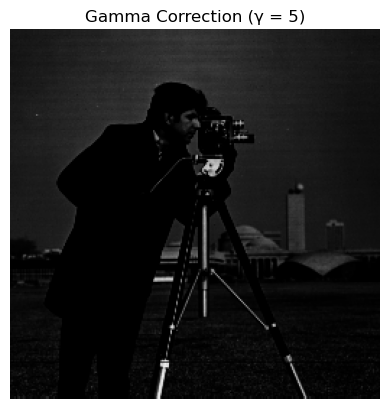

In [68]:
# ── 3. Power-law / Gamma correction ───────────────

gamma = 5
normalized = img_arr / 255.0
gamma_image = 255 * (normalized ** gamma)

gamma_image = Image.fromarray(gamma_image)
plt.imshow(gamma_image, cmap='gray')
plt.title(f"Gamma Correction (γ = {gamma})")
plt.axis("off")
plt.show()